In [89]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive


drive.mount("/content/drive")
%cd /content/drive/MyDrive/MA/data

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/MA/data


In [90]:
adult_data = pd.read_csv("adult.csv")
adult_data.head()

,Unnamed: 0,age,workclass,education,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,salary,salary K$
0,0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,40,United-States,<=50K,39
1,1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,13,United-States,<=50K,35
2,2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,40,United-States,<=50K,27
3,3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,40,United-States,<=50K,43
4,4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,40,Cuba,<=50K,25


# Прочитай набір даних із CSV-файлу та виконай очищення даних — видали усі рядки, які містять символ "?" у будь-яких стовпцях. Також перевір коректність даних (зарплата та зарплата у $K).

In [91]:
adult_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0      32561 non-null  int64 
 1   age             32561 non-null  int64 
 2   workclass       32561 non-null  object
 3   education       32561 non-null  object
 4   marital-status  32561 non-null  object
 5   occupation      32561 non-null  object
 6   relationship    32561 non-null  object
 7   race            32561 non-null  object
 8   sex             32561 non-null  object
 9   hours-per-week  32561 non-null  int64 
 10  native-country  32561 non-null  object
 11  salary          32561 non-null  object
 12  salary K$       32561 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 3.2+ MB


In [92]:
(adult_data == "?").sum()

,0
Unnamed: 0,0
age,0
workclass,1836
education,0
marital-status,0
occupation,1843
relationship,0
race,0
sex,0
hours-per-week,0


In [93]:
adult_data = adult_data.replace("?", np.nan)
adult_data = adult_data.dropna()
(adult_data == "?").sum()

,0
Unnamed: 0,0
age,0
workclass,0
education,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0
hours-per-week,0


In [94]:
adult_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30162 entries, 0 to 32560
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0      30162 non-null  int64 
 1   age             30162 non-null  int64 
 2   workclass       30162 non-null  object
 3   education       30162 non-null  object
 4   marital-status  30162 non-null  object
 5   occupation      30162 non-null  object
 6   relationship    30162 non-null  object
 7   race            30162 non-null  object
 8   sex             30162 non-null  object
 9   hours-per-week  30162 non-null  int64 
 10  native-country  30162 non-null  object
 11  salary          30162 non-null  object
 12  salary K$       30162 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 3.2+ MB


In [95]:
adult_data.describe()

,Unnamed: 0,age,hours-per-week,salary K$
count,30162.000000,30162.000000,30162.000000,30162.000000
mean,16287.103242,38.437902,40.931238,73.968570
std,9383.401676,13.134665,11.979984,85.365144
min,0.000000,17.000000,1.000000,15.000000
25%,8178.250000,28.000000,40.000000,26.000000
50%,16285.500000,37.000000,40.000000,38.000000
75%,24401.750000,47.000000,45.000000,49.000000
max,32560.000000,90.000000,99.000000,349.000000


In [96]:
adult_data["salary"].nunique()

2

In [97]:
adult_data["salary"].value_counts()

,count
salary,
<=50K,22654
>50K,7508


In [98]:
adult_data["check_salary"] = (
    ((adult_data["salary"] == "<=50K") & (adult_data["salary K$"] <= 50)) |
    ((adult_data["salary"] == ">50K") & (adult_data["salary K$"] > 50))
)

print(adult_data["check_salary"].value_counts())

check_salary
True    30162
Name: count, dtype: int64


In [99]:
adult_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30162 entries, 0 to 32560
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0      30162 non-null  int64 
 1   age             30162 non-null  int64 
 2   workclass       30162 non-null  object
 3   education       30162 non-null  object
 4   marital-status  30162 non-null  object
 5   occupation      30162 non-null  object
 6   relationship    30162 non-null  object
 7   race            30162 non-null  object
 8   sex             30162 non-null  object
 9   hours-per-week  30162 non-null  int64 
 10  native-country  30162 non-null  object
 11  salary          30162 non-null  object
 12  salary K$       30162 non-null  int64 
 13  check_salary    30162 non-null  bool  
dtypes: bool(1), int64(4), object(9)
memory usage: 3.3+ MB


In [100]:
adult_data = adult_data.rename(columns={"Unnamed: 0": "id"})

In [101]:
adult_data.head()

,id,age,workclass,education,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,salary,salary K$,check_salary
0,0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,40,United-States,<=50K,39,True
1,1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,13,United-States,<=50K,35,True
2,2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,40,United-States,<=50K,27,True
3,3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,40,United-States,<=50K,43,True
4,4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,40,Cuba,<=50K,25,True


# Отримай середнє і стандартне відхилення віку для людей, які заробляють > 50K на рік. Після цього, отримай його для тих, хто заробляє <= 50K.

In [102]:
print(adult_data.groupby("salary")["age"].describe())

          count      mean        std   min   25%   50%   75%   max
salary                                                            
<=50K   22654.0  36.60806  13.464631  17.0  26.0  34.0  45.0  90.0
>50K     7508.0  43.95911  10.269633  19.0  36.0  43.0  51.0  90.0


# Проаналізуй кореляцію між даними.

In [103]:
corr_matrix = adult_data.select_dtypes(include=["int64", "float64"]).corr()
print(corr_matrix)

                      id       age  hours-per-week  salary K$
id              1.000000 -0.001126       -0.001890   0.000129
age            -0.001126  1.000000        0.101599   0.208203
hours-per-week -0.001890  0.101599        1.000000   0.196378
salary K$       0.000129  0.208203        0.196378   1.000000


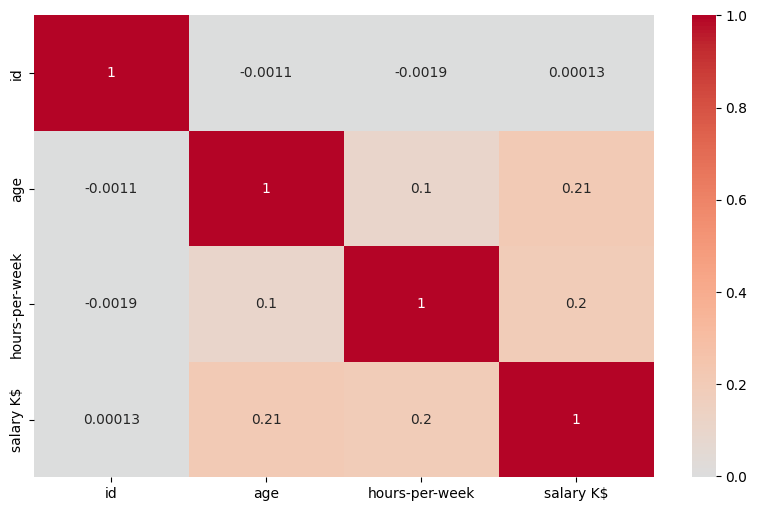

In [104]:
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.show()

In [105]:
adult_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30162 entries, 0 to 32560
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              30162 non-null  int64 
 1   age             30162 non-null  int64 
 2   workclass       30162 non-null  object
 3   education       30162 non-null  object
 4   marital-status  30162 non-null  object
 5   occupation      30162 non-null  object
 6   relationship    30162 non-null  object
 7   race            30162 non-null  object
 8   sex             30162 non-null  object
 9   hours-per-week  30162 non-null  int64 
 10  native-country  30162 non-null  object
 11  salary          30162 non-null  object
 12  salary K$       30162 non-null  int64 
 13  check_salary    30162 non-null  bool  
dtypes: bool(1), int64(4), object(9)
memory usage: 3.3+ MB


In [106]:
adult_data.drop(columns=["check_salary"], inplace=True)
adult_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30162 entries, 0 to 32560
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              30162 non-null  int64 
 1   age             30162 non-null  int64 
 2   workclass       30162 non-null  object
 3   education       30162 non-null  object
 4   marital-status  30162 non-null  object
 5   occupation      30162 non-null  object
 6   relationship    30162 non-null  object
 7   race            30162 non-null  object
 8   sex             30162 non-null  object
 9   hours-per-week  30162 non-null  int64 
 10  native-country  30162 non-null  object
 11  salary          30162 non-null  object
 12  salary K$       30162 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 3.2+ MB


In [107]:
adult_data["salary"] = adult_data["salary"].map({">50K": True, "<=50K": False})
print(adult_data["salary"].unique())
print(adult_data["salary"].dtype)

[False  True]
bool


In [110]:
# Кодуємо всі категоріальні змінні автоматично
adult_encoded = pd.get_dummies(adult_data, drop_first=True)

# Обчислюємо кореляцію з колонкою salary (булева True/False для >50K)
corr_with_salary = adult_encoded.corr()["salary"].sort_values(ascending=False)

print("Топ 10 позитивних кореляцій:")
print(corr_with_salary.head(10))

print("\nТоп 10 негативних кореляцій:")
print(corr_with_salary.tail(10))

Топ 10 позитивних кореляцій:
salary                               1.000000
salary K$                            0.853894
marital-status_Married-civ-spouse    0.445418
age                                  0.241998
hours-per-week                       0.229480
sex_Male                             0.216699
occupation_Exec-managerial           0.213442
occupation_Prof-specialty            0.181458
education_Bachelors                  0.178847
education_Masters                    0.174126
Name: salary, dtype: float64

Топ 10 негативних кореляцій:
education_11th                 -0.084522
race_Black                     -0.088332
occupation_Handlers-cleaners   -0.093836
workclass_Private              -0.117218
education_HS-grad              -0.136137
relationship_Unmarried         -0.145799
occupation_Other-service       -0.165934
relationship_Not-in-family     -0.193258
relationship_Own-child         -0.226186
marital-status_Never-married   -0.320053
Name: salary, dtype: float64


Топ позитивних кореляцій із доходом >50K
- Одружені чоловіки мають значно більший шанс заробляти >50K
- Старші люди частіше мають високий дохід
- Більше годин роботи → більше шансів на >50K
- Чоловіки частіше заробляють більше
- Керівні посади корелюють з високою зарплатою
- Спеціалісти (лікарі, інженери) — теж
- Вища освіта підвищує шанси на >50K

Топ негативних кореляцій
- Неодружені значно рідше мають >50K)
- Батьки одинаки, незаміжні, самотні люди частіше мають низьку зарплату
- Працюючі у сфері послуг — мають низьку зарплату
- Лише середня освіта — нижчий дохід
- Чорношкірі люди частіше мають нижчу зарплату
- Приватний сектор в цілому — нижчі зарплати

Найвпливовіші фактори для зарплати >50K:
- Сімейний стан — одружені мають найсильнішу кореляцію (+0.45 vs -0.32)
- Вік і години роботи — підтверджують попередній аналіз числових змінних
- Освіта — бакалавр і магістр позитивно впливають; лише середня школа — негативно
- Професія — керівники та спеціалісти заробляють більше; сфера послуг — менше
- Стать — помітний гендерний розрив (0.217)